# Q-learning Experiments

This notebook runs the Phase 1 Q-learning baseline for the static maze environment.

It covers:

- environment inspection
- tabular Q-learning training
- greedy evaluation
- metrics summary
- Q-table saving
- learning and policy visualizations when matplotlib is available

Only Q-learning is used here. DQN, PPO, and SAC are intentionally left out.

## 1. Notebook Setup

Run this first so imports work whether the notebook is opened from the project root or from the `notebooks/` folder.

In [40]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/home/hiba/Desktop/maze project/Maze-and-Path-Finding')

In [41]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.agents import QLearningAgent
from src.env import LEVEL_SIZES, MazeEnv, ACTION_NAMES
from src.training.evaluator import evaluate_qlearning
from src.training.trainer_qlearning import train_qlearning, rollout_greedy_path
from src.utils.io import DIRS, ensure_dirs, figure_path, save_metrics, save_qtable
from src.utils.seed import set_global_seed
from src.visualization import plot_maze

ensure_dirs()
print("Imports ready")


Imports ready


## 2. Experiment Configuration

For a fast test, set `EPISODES = 20` or `100`. For the actual baseline, use `EPISODES = 5000`.

In [42]:
LEVEL = "large"  # tiny=8, small=10, medium=20, large=50
SIZE = LEVEL_SIZES[LEVEL]
DIFFICULTY = "hard"  # easy, medium, hard
SEED = 7
EPISODES = 5000
LOG_EVERY = 100

ALPHA = 0.1
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995

RUN_ID = f"qlearning_{LEVEL}_{DIFFICULTY}_seed{SEED}"
RUN_ID

'qlearning_large_hard_seed7'

## 3. Create and Inspect the Maze Environment

In [43]:
set_global_seed(SEED)

env = MazeEnv(level=LEVEL, difficulty=DIFFICULTY, seed=SEED)
env.action_space.seed(SEED)

obs, info = env.reset()

print("Level:", env.level)
print("Difficulty:", env.difficulty)
print("Maze size:", env.size)
print("Observation shape:", obs.shape)
print("Action space:", env.action_space.n)
print("Start:", env.start_pos)
print("Goal:", env.goal_pos)
print("Max steps:", env.max_steps)
print("Optimal path length:", info["optimal_path_len"])
print("Actions:", ACTION_NAMES)

Level: large
Difficulty: hard
Maze size: 50
Observation shape: (2500,)
Action space: 4
Start: (0, 0)
Goal: (49, 49)
Max steps: 10000
Optimal path length: 118
Actions: {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}


Display the generated maze with dark walls, white rooms/free cells, blue start, green goal, and the BFS shortest path in orange.


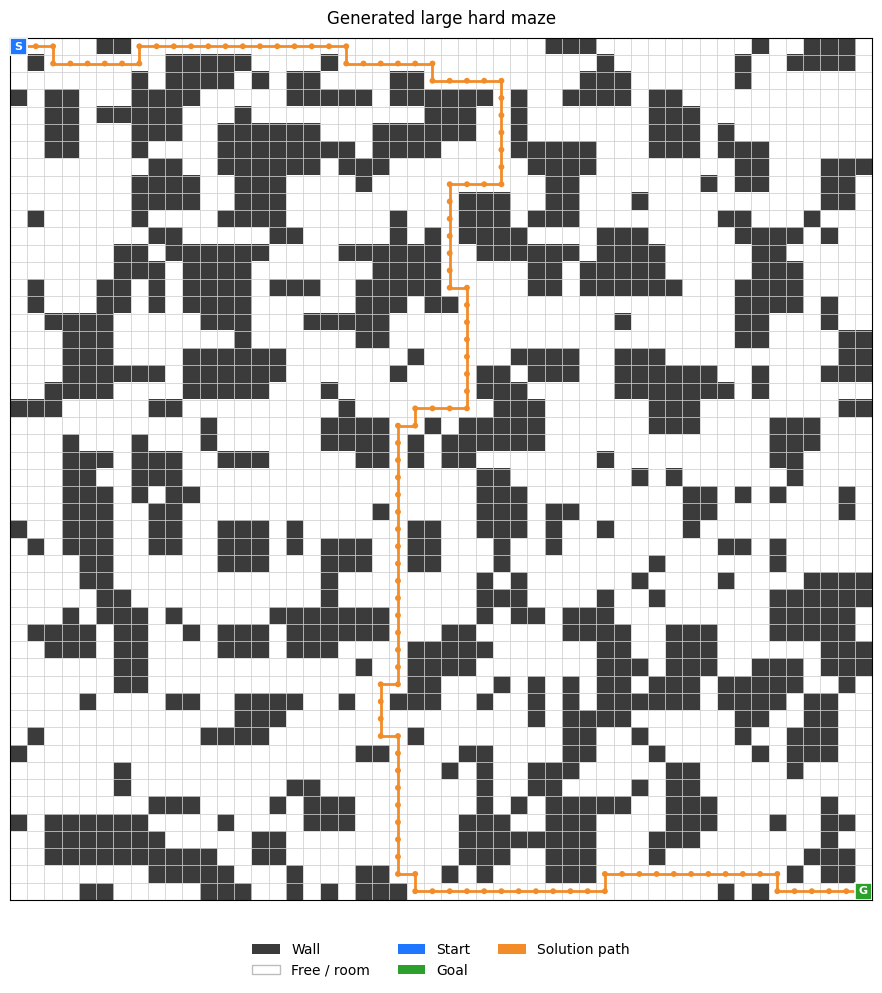

In [44]:
try:
    fig, ax = plot_maze(
        env,
        title=f"Generated {LEVEL} {DIFFICULTY} maze",
        save_path=figure_path(RUN_ID, "maze_layout"),
    )
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)


## 4. Create the Q-learning Agent

In [45]:
agent = QLearningAgent(
    n_states=env.size * env.size,
    n_actions=env.action_space.n,
    learning_rate=ALPHA,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_end=EPSILON_END,
    epsilon_decay=EPSILON_DECAY,
    seed=SEED,
)

print("Q-table shape:", agent.q_table.shape)
print("Initial epsilon:", agent.epsilon)

Q-table shape: (2500, 4)
Initial epsilon: 1.0


## 5. Train Q-learning

This cell can take longer when `EPISODES = 5000`. For quick debugging, reduce the value in the configuration cell.

In [46]:
result = train_qlearning(
    env=env,
    agent=agent,
    episodes=EPISODES,
    log_every=LOG_EVERY,
    logger=None,
    capture_paths=True,
)

summary = result.tracker.compute_summary()
summary

Episode   100/5000 | return=-115.175 | steps=3782 | success=1 | eps=0.609 | rolling_success=45.00%
Episode   200/5000 | return=-64.987 | steps=3228 | success=1 | eps=0.369 | rolling_success=98.00%
Episode   300/5000 | return= -7.663 | steps=1518 | success=1 | eps=0.223 | rolling_success=100.00%
Episode   400/5000 | return=  4.709 | steps= 508 | success=1 | eps=0.135 | rolling_success=100.00%
Episode   500/5000 | return=  5.581 | steps= 533 | success=1 | eps=0.082 | rolling_success=100.00%
Episode   600/5000 | return=  6.241 | steps=1069 | success=1 | eps=0.050 | rolling_success=100.00%
Episode   700/5000 | return=  7.941 | steps=1163 | success=1 | eps=0.030 | rolling_success=100.00%
Episode   800/5000 | return=  8.319 | steps= 785 | success=1 | eps=0.018 | rolling_success=100.00%
Episode   900/5000 | return=  9.285 | steps= 417 | success=1 | eps=0.011 | rolling_success=100.00%
Episode  1000/5000 | return=  9.791 | steps= 210 | success=1 | eps=0.010 | rolling_success=100.00%
Episode  11

{'success_rate': 1.0,
 'mean_return': 9.798,
 'std_return': 0.1474,
 'mean_steps_to_goal': 119.32,
 'std_steps_to_goal': 1.42,
 'convergence_episode': 159,
 'sample_efficiency': 1126372.0,
 'path_optimality': 0.9889,
 'optimal_path_len': 118,
 'total_episodes': 5000}

## 6. Evaluate the Greedy Policy

Evaluation uses `training=False`, so the agent acts greedily with no epsilon exploration.

In [47]:
eval_result = evaluate_qlearning(env, agent, episodes=100)

eval_summary = {
    "eval_success_rate": round(eval_result.success_rate, 4),
    "eval_mean_return": round(eval_result.mean_return, 4),
    "eval_mean_steps": round(eval_result.mean_steps, 2),
}

eval_summary

{'eval_success_rate': 1.0, 'eval_mean_return': 9.883, 'eval_mean_steps': 118.0}

## 7. Save Experiment Outputs

In [48]:
full_summary = {
    **summary,
    **eval_summary,
    "maze_size": env.size,
    "max_steps": env.max_steps,
    "run_id": RUN_ID,
}

qtable_path = save_qtable(agent.q_table, RUN_ID)
metrics_path = save_metrics(
    {
        "episodes": result.tracker.episodes_arr,
        "rewards": result.tracker.rewards,
        "steps": result.tracker.steps_arr,
        "success": result.tracker.success_arr,
    },
    RUN_ID,
)

summary_path = DIRS["logs"] / f"{RUN_ID}_notebook_summary.json"
summary_path.write_text(json.dumps(full_summary, indent=2, default=str), encoding="utf-8")

paths_path = DIRS["metrics"] / f"{RUN_ID}_notebook_paths.json"
paths_json = {
    name: [[int(r), int(c)] for r, c in path]
    for name, path in result.paths.items()
}
paths_path.write_text(json.dumps(paths_json, indent=2), encoding="utf-8")

print("Q-table:", qtable_path)
print("Metrics:", metrics_path)
print("Summary:", summary_path)
print("Paths:", paths_path)

  [io] Q-table saved -> /home/hiba/Desktop/maze project/Maze-and-Path-Finding/models/qlearning/qlearning_large_hard_seed7.npy
  [io] metrics saved -> /home/hiba/Desktop/maze project/Maze-and-Path-Finding/results/metrics/qlearning_large_hard_seed7_metrics.npz
Q-table: /home/hiba/Desktop/maze project/Maze-and-Path-Finding/models/qlearning/qlearning_large_hard_seed7.npy
Metrics: /home/hiba/Desktop/maze project/Maze-and-Path-Finding/results/metrics/qlearning_large_hard_seed7_metrics.npz
Summary: /home/hiba/Desktop/maze project/Maze-and-Path-Finding/results/logs/qlearning_large_hard_seed7_notebook_summary.json
Paths: /home/hiba/Desktop/maze project/Maze-and-Path-Finding/results/metrics/qlearning_large_hard_seed7_notebook_paths.json


## 8. Learning Curves

/tmp/ipykernel_316037/119325699.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/tmp/ipykernel_316037/119325699.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


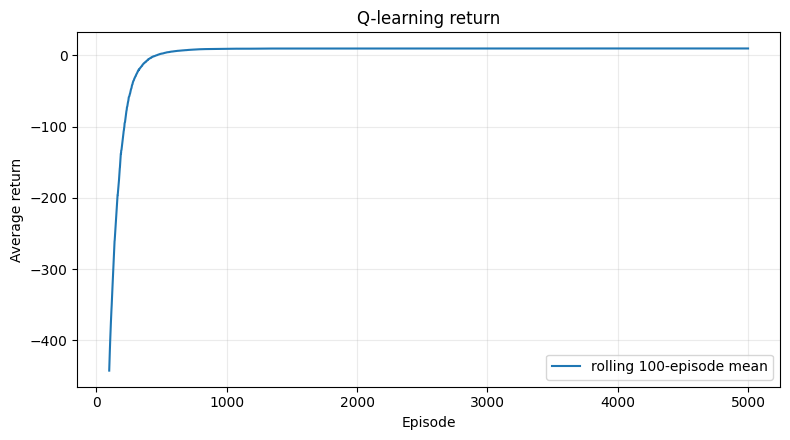

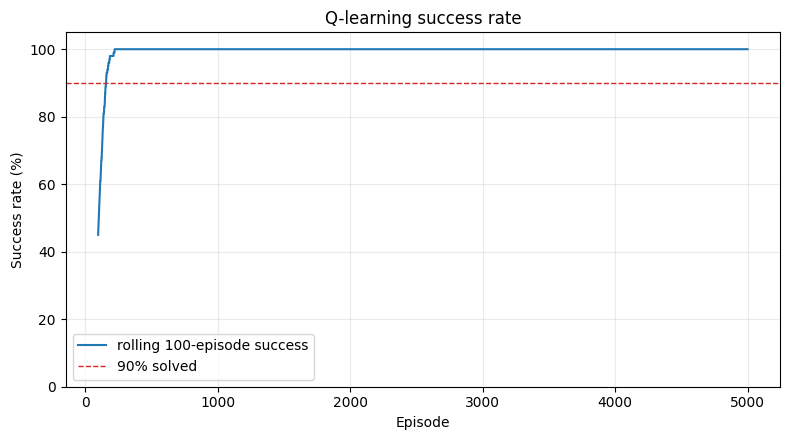

In [49]:
try:
    from src.visualization.plots import plot_learning_curve, plot_success_curve

    fig1 = plot_learning_curve(result.tracker.rewards, window=100)
    fig1.savefig(figure_path(RUN_ID, "notebook_learning_curve"), dpi=150)
    fig1.show()

    fig2 = plot_success_curve(result.tracker.success_arr, window=100)
    fig2.savefig(figure_path(RUN_ID, "notebook_success_curve"), dpi=150)
    fig2.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 9. Q-value Heatmap and Policy Map

/tmp/ipykernel_316037/3563132546.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig3.show()
/tmp/ipykernel_316037/3563132546.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig4.show()


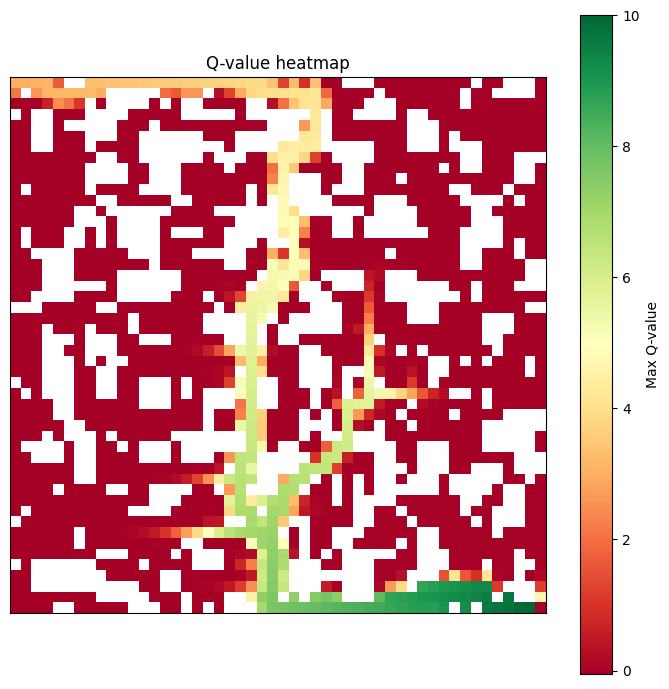

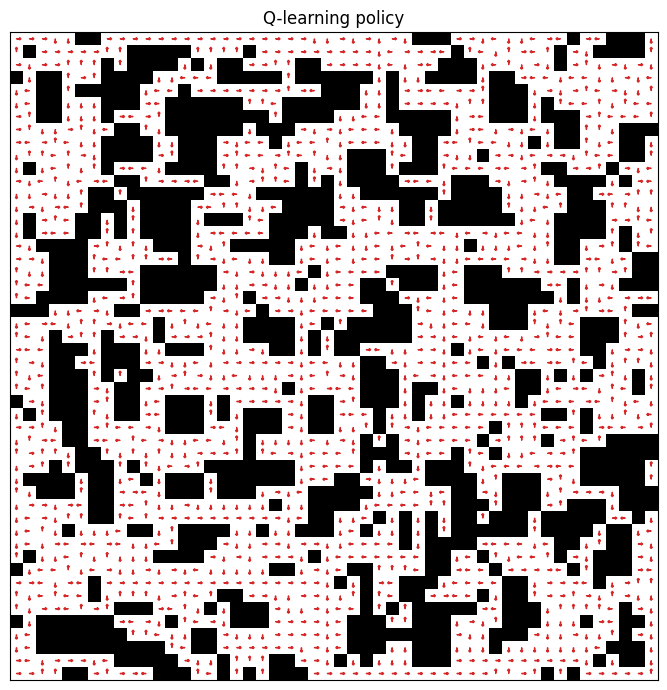

In [50]:
try:
    from src.visualization.heatmaps import plot_q_heatmap
    from src.visualization.policy_maps import plot_policy_arrows

    fig3 = plot_q_heatmap(agent.q_table, env.maze)
    fig3.savefig(figure_path(RUN_ID, "notebook_q_heatmap"), dpi=150)
    fig3.show()

    fig4 = plot_policy_arrows(agent.q_table, env.maze)
    fig4.savefig(figure_path(RUN_ID, "notebook_policy_map"), dpi=150)
    fig4.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 13. Hyperparameter Tuning

This grid search trains Q-learning on small, medium, and large mazes using the default difficulty. It tunes learning rate, epsilon decay, and gamma only.


In [51]:
from itertools import product

TUNING_LEVELS = ["small", "medium", "large"]
TUNING_LEARNING_RATES = [0.05, 0.1, 0.3]
TUNING_EPSILON_DECAYS = [0.99, 0.995, 0.999]
TUNING_GAMMAS = [0.95, 0.99]
TUNING_EPISODES = 3000
TUNING_EVAL_EPISODES = 100

len(TUNING_LEVELS) * len(TUNING_LEARNING_RATES) * len(TUNING_EPSILON_DECAYS) * len(TUNING_GAMMAS)


54

In [52]:
tuning_rows = []

for level in TUNING_LEVELS:
    for learning_rate, epsilon_decay, gamma in product(
        TUNING_LEARNING_RATES,
        TUNING_EPSILON_DECAYS,
        TUNING_GAMMAS,
    ):
        tuning_env = MazeEnv(level=level, difficulty=DIFFICULTY, seed=SEED)
        tuning_env.action_space.seed(SEED)

        tuning_agent = QLearningAgent(
            n_states=tuning_env.size * tuning_env.size,
            n_actions=tuning_env.action_space.n,
            learning_rate=learning_rate,
            gamma=gamma,
            epsilon_start=EPSILON_START,
            epsilon_end=EPSILON_END,
            epsilon_decay=epsilon_decay,
            seed=SEED,
        )

        tuning_result = train_qlearning(
            tuning_env,
            tuning_agent,
            episodes=TUNING_EPISODES,
            log_every=0,
            capture_paths=False,
        )
        tuning_eval = evaluate_qlearning(
            tuning_env,
            tuning_agent,
            episodes=TUNING_EVAL_EPISODES,
        )

        tuning_rows.append({
            "level": level,
            "maze_size": tuning_env.size,
            "difficulty": DIFFICULTY,
            "learning_rate": learning_rate,
            "epsilon_decay": epsilon_decay,
            "gamma": gamma,
            "episodes": TUNING_EPISODES,
            "eval_episodes": TUNING_EVAL_EPISODES,
            "success_rate": tuning_eval.success_rate,
            "mean_return": tuning_eval.mean_return,
            "mean_steps": tuning_eval.mean_steps,
            "train_final_rolling_success": tuning_result.tracker.rolling_success_rate() or 0.0,
        })

        print(
            f"{level:>6} | alpha={learning_rate:<4} eps_decay={epsilon_decay:<5} "
            f"gamma={gamma:<4} | success={tuning_eval.success_rate:.2%} "
            f"return={tuning_eval.mean_return:.3f} steps={tuning_eval.mean_steps:.1f}"
        )

tuning_results_df = pd.DataFrame(tuning_rows)
tuning_results_df


 small | alpha=0.05 eps_decay=0.99  gamma=0.95 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.05 eps_decay=0.99  gamma=0.99 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.05 eps_decay=0.995 gamma=0.95 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.05 eps_decay=0.995 gamma=0.99 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.05 eps_decay=0.999 gamma=0.95 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.05 eps_decay=0.999 gamma=0.99 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.1  eps_decay=0.99  gamma=0.95 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.1  eps_decay=0.99  gamma=0.99 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.1  eps_decay=0.995 gamma=0.95 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.1  eps_decay=0.995 gamma=0.99 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.1  eps_decay=0.999 gamma=0.95 | success=100.00% return=9.971 steps=30.0
 small | alpha=0.1  e

,level,maze_size,difficulty,learning_rate,epsilon_decay,gamma,episodes,eval_episodes,success_rate,mean_return,mean_steps,train_final_rolling_success
0,small,10,hard,0.05,0.990,0.95,3000,100,1.0,9.971,30.0,1.0
1,small,10,hard,0.05,0.990,0.99,3000,100,1.0,9.971,30.0,1.0
2,small,10,hard,0.05,0.995,0.95,3000,100,1.0,9.971,30.0,1.0
3,small,10,hard,0.05,0.995,0.99,3000,100,1.0,9.971,30.0,1.0
4,small,10,hard,0.05,0.999,0.95,3000,100,1.0,9.971,30.0,1.0
5,small,10,hard,0.05,0.999,0.99,3000,100,1.0,9.971,30.0,1.0
6,small,10,hard,0.10,0.990,0.95,3000,100,1.0,9.971,30.0,1.0
7,small,10,hard,0.10,0.990,0.99,3000,100,1.0,9.971,30.0,1.0
8,small,10,hard,0.10,0.995,0.95,3000,100,1.0,9.971,30.0,1.0
9,small,10,hard,0.10,0.995,0.99,3000,100,1.0,9.971,30.0,1.0


In [53]:
best_by_level = (
    tuning_results_df
    .sort_values(
        ["level", "success_rate", "mean_return", "mean_steps"],
        ascending=[True, False, False, True],
    )
    .groupby("level", as_index=False)
    .first()
)

for _, row in best_by_level.iterrows():
    print(
        f"Best for {row['level']} ({int(row['maze_size'])}x{int(row['maze_size'])}): "
        f"alpha={row['learning_rate']}, epsilon_decay={row['epsilon_decay']}, "
        f"gamma={row['gamma']} | success={row['success_rate']:.2%}, "
        f"mean_return={row['mean_return']:.3f}, mean_steps={row['mean_steps']:.1f}"
    )

best_by_level


Best for large (50x50): alpha=0.05, epsilon_decay=0.99, gamma=0.95 | success=100.00%, mean_return=9.883, mean_steps=118.0
Best for medium (20x20): alpha=0.05, epsilon_decay=0.99, gamma=0.95 | success=100.00%, mean_return=9.941, mean_steps=60.0
Best for small (10x10): alpha=0.05, epsilon_decay=0.99, gamma=0.95 | success=100.00%, mean_return=9.971, mean_steps=30.0


,level,maze_size,difficulty,learning_rate,epsilon_decay,gamma,episodes,eval_episodes,success_rate,mean_return,mean_steps,train_final_rolling_success
0,large,50,hard,0.05,0.99,0.95,3000,100,1.0,9.883,118.0,1.0
1,medium,20,hard,0.05,0.99,0.95,3000,100,1.0,9.941,60.0,1.0
2,small,10,hard,0.05,0.99,0.95,3000,100,1.0,9.971,30.0,1.0


## 14. Final Visualizations


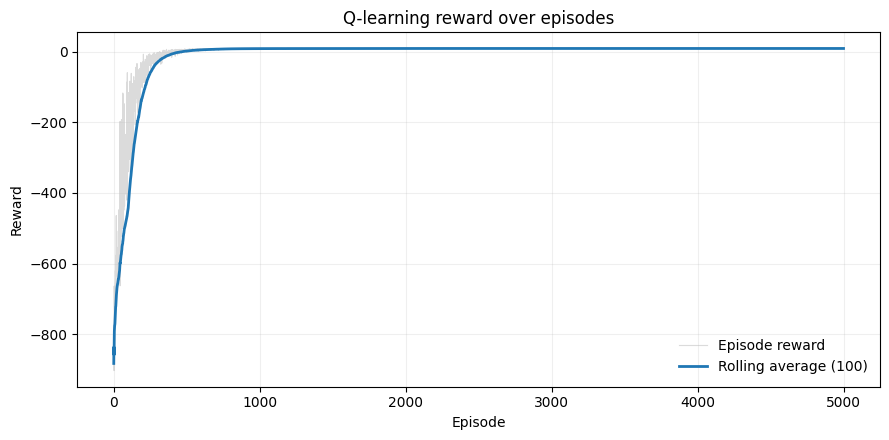

In [54]:
reward_values = np.asarray(result.tracker.rewards, dtype=float)
episodes = np.arange(1, len(reward_values) + 1)
reward_roll = pd.Series(reward_values).rolling(window=100, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(episodes, reward_values, color="0.75", linewidth=0.8, alpha=0.55, label="Episode reward")
ax.plot(episodes, reward_roll, color="tab:blue", linewidth=2.0, label="Rolling average (100)")
ax.set_title("Q-learning reward over episodes")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


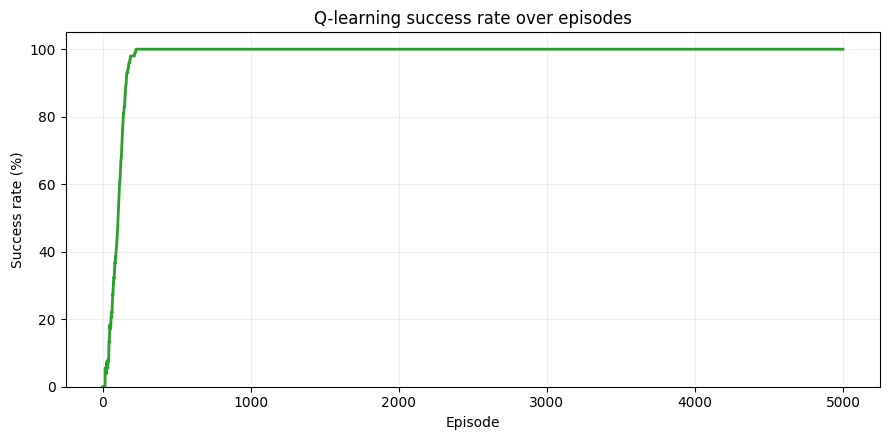

In [55]:
success_values = np.asarray(result.tracker.success_arr, dtype=float)
episodes = np.arange(1, len(success_values) + 1)
success_roll = pd.Series(success_values).rolling(window=100, min_periods=1).mean() * 100.0

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(episodes, success_roll, color="tab:green", linewidth=2.0)
ax.set_title("Q-learning success rate over episodes")
ax.set_xlabel("Episode")
ax.set_ylabel("Success rate (%)")
ax.set_ylim(0, 105)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


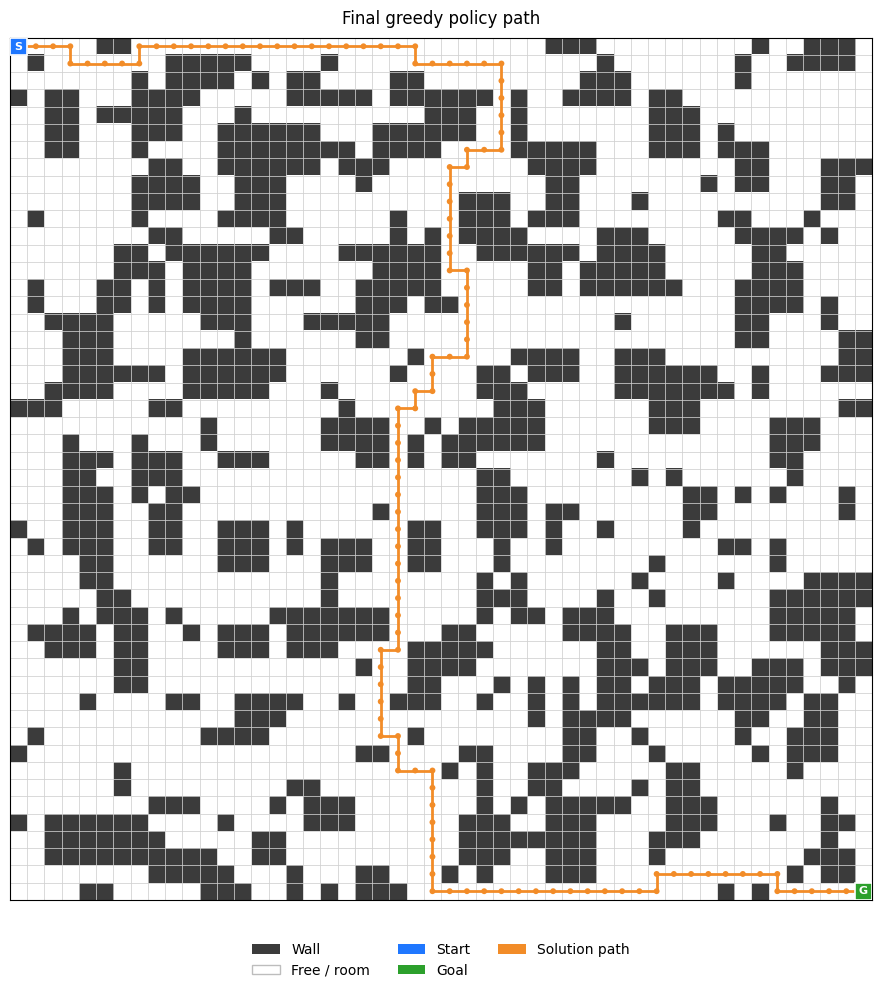

In [56]:
final_greedy_path = rollout_greedy_path(env, agent)

fig, ax = plot_maze(
    env,
    path=final_greedy_path,
    show_solution=False,
    title="Final greedy policy path",
)
plt.show()
